In [ ]:
# [Dataset: IRIS dataset available in sklearn.datasets]
# 1. Implement linear SVM on the Iris dataset (multiclass classification):
# ● Load the iris dataset. Normalize the feature values.
# ● Split the dataset into train and test (80:20).
# ● Implement a linear SVM:
# 1. Find the maximum margin function with parameters W
# and b.
# 2. Construct a quadratic objective function and define
# constraints.
# 3. Solve the problem using a quadratic programming solver.
# 4. Compute vector W, which is perpendicular to the decision
# line.
# 5. Find the decision line and utilize it for classification of
# unknown samples.

# ● Report accuracy, precision, recall and F1-score. Also display
# the confusion matrix.

In [ ]:
!pip install cvxopt --quiet

In [ ]:
# Dual-form (Wolfe) linear soft-margin SVM implemented with cvxopt
# One-vs-Rest multiclass on Iris; includes 2D decision-region plot.

import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from cvxopt import matrix, solvers

# quiet cvxopt output
solvers.options['show_progress'] = False

# def train_linear_svm_dual(X, y, C=1.0, eps=1e-6):
#     """
#     Train linear SVM using the dual QP (Wolfe):
#       maximize sum alpha_i - 1/2 sum_i,j alpha_i alpha_j y_i y_j <x_i,x_j>
#       s.t. 0 <= alpha_i <= C,  sum_i alpha_i y_i = 0

#     Returns:
#       w (d,), b (float), alphas (n,), sv_idx (list indices)
#     """
#     X = np.asarray(X, dtype=float)
#     y = np.asarray(y, dtype=float)
#     n, d = X.shape

#     # Kernel (linear): Gram matrix
#     K = X.dot(X.T)  # shape (n, n)

#     # P (cvxopt expects P for 1/2 x^T P x in minimization). We want to minimize -W(alpha) = 1/2 alpha^T (YKY) alpha - 1^T alpha
#     Y = np.outer(y, y)
#     P = matrix(Y * K + 1e-10*np.eye(n))  # small jitter for numerical stability
#     q = matrix(-np.ones(n))

#     # G, h for box constraints: 0 <= alpha_i <= C  ->  -alpha <= 0  and  alpha <= C
#     G_std = np.vstack((-np.eye(n), np.eye(n)))
#     h_std = np.hstack((np.zeros(n), np.ones(n) * C))

#     G = matrix(G_std)
#     h = matrix(h_std)

#     # Equality constraint: sum alpha_i y_i = 0
#     A = matrix(y.reshape(1, -1))
#     b = matrix(0.0)

#     # Solve QP
#     sol = solvers.qp(P, q, G, h, A, b)
#     alphas = np.array(sol['x']).reshape((-1,))

#     # Numerical tolerance: subset support vectors
#     sv_idx = np.where(alphas > eps)[0]

#     # compute w from alphas
#     w = ((alphas * y)[:, None] * X).sum(axis=0)  # shape (d,)

#     # compute b: use support vectors with 0 < alpha < C (i.e., margin SVs) if available
#     margin_sv = np.where((alphas > eps) & (alphas < C - 1e-8))[0]
#     if len(margin_sv) > 0:
#         b_vals = y[margin_sv] - X[margin_sv].dot(w)
#         b = np.mean(b_vals)
#     else:
#         # fallback: use any support vector (may be less stable)
#         if len(sv_idx) > 0:
#             b_vals = y[sv_idx] - X[sv_idx].dot(w)
#             b = np.mean(b_vals)
#         else:
#             b = 0.0

#     return w, float(b), alphas, sv_idx

def train_linear_svm_dual(X, y, C=1.0, eps=1e-6):
    """
    Train linear SVM using the dual QP (Wolfe):
      maximize sum alpha_i - 1/2 sum_i,j alpha_i alpha_j y_i y_j <x_i,x_j>
      s.t. alpha_i >= 0,  sum_i alpha_i y_i = 0

    Returns:
      w (d,), b (float), alphas (n,), sv_idx (list indices)
    """
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    n, d = X.shape

    # Kernel (linear): Gram matrix
    K = X.dot(X.T)  # shape (n, n)

    # P (cvxopt expects P for 1/2 x^T P x in minimization).
    Y = np.outer(y, y)
    P = matrix(Y * K + 1e-10*np.eye(n))  # small jitter for numerical stability
    q = matrix(-np.ones(n))

    # G, h for constraint: alpha_i >= 0  ->  -alpha_i <= 0
    G_std = -np.eye(n)
    h_std = np.zeros(n)

    G = matrix(G_std)
    h = matrix(h_std)

    # Equality constraint: sum alpha_i y_i = 0
    A = matrix(y.reshape(1, -1))
    b = matrix(0.0)

    # Solve QP
    sol = solvers.qp(P, q, G, h, A, b)
    alphas = np.array(sol['x']).reshape((-1,))

    # Numerical tolerance: subset support vectors
    sv_idx = np.where(alphas > eps)[0]

    # compute w from alphas
    w = ((alphas * y)[:, None] * X).sum(axis=0)  # shape (d,)

    # compute b: use support vectors (alpha > eps)
    if len(sv_idx) > 0:
        b_vals = y[sv_idx] - X[sv_idx].dot(w)
        b = np.mean(b_vals)
    else:
        b = 0.0

    return w, float(b), alphas, sv_idx


In [ ]:
# One-vs-Rest helpers

def train_ovr_svm_dual(X_train, y_train, C=1.0):
    classes = np.unique(y_train)
    models = {}
    for cls in classes:
        # binary labels: +1 for the class, -1 for others
        y_bin = np.where(y_train == cls, 1.0, -1.0)
        w, b, alphas, sv_idx = train_linear_svm_dual(X_train, y_bin, C=C)
        models[cls] = {'w': w, 'b': b, 'alphas': alphas, 'sv_idx': sv_idx}
        print(f"[OVR] Trained classifier for class {cls}: #SV = {len(sv_idx)}")
    return models

def predict_ovr(models, X):
    X = np.asarray(X)
    classes = list(models.keys())
    scores = np.vstack([X.dot(models[c]['w']) + models[c]['b'] for c in classes]).T
    idx = np.argmax(scores, axis=1)
    preds = np.array([classes[i] for i in idx])
    return preds

In [ ]:
# Load data, normalize, split (same as your flow)

iris = datasets.load_iris()
X = iris.data  # 4 features
y = iris.target

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_full)
X_test = scaler.transform(X_test_full)

In [ ]:
# Train OVR SVMs (dual)

C = 1.0
models = train_ovr_svm_dual(X_train, y_train, C=C)

print("\nLearned parameters (w and b) for each one-vs-rest classifier:")
for cls, m in models.items():
    w, b = m['w'], m['b']
    print(f"Class {cls}: w = {np.round(w,4)}, b = {np.round(b,4)}, ||w|| = {np.linalg.norm(w):.4f}")

[OVR] Trained classifier for class 0: #SV = 3
[OVR] Trained classifier for class 1: #SV = 100
[OVR] Trained classifier for class 2: #SV = 11

Learned parameters (w and b) for each one-vs-rest classifier:
Class 0: w = [-0.4526  0.3436 -0.8679 -0.9416], b = -1.4886, ||w|| = 1.4010
Class 1: w = [-0.1736 -0.4226  1.1341 -0.9632], b = -0.376, ||w|| = 1.5565
Class 2: w = [-0.5578 -1.0626  5.0058  4.2853], b = -6.2516, ||w|| = 6.6979


In [ ]:
# Predict and evaluate

y_pred = predict_ovr(models, X_test)
print("\nEvaluation on test set (80:20 split):")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report (precision, recall, f1):\n")
print(classification_report(y_test, y_pred, target_names=iris.target_names))
print("Confusion matrix:\n")
print(confusion_matrix(y_test, y_pred))


Evaluation on test set (80:20 split):
Accuracy: 1.0

Classification report (precision, recall, f1):

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion matrix:

[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


[OVR] Trained classifier for class 0: #SV = 4
[OVR] Trained classifier for class 1: #SV = 119
[OVR] Trained classifier for class 2: #SV = 17


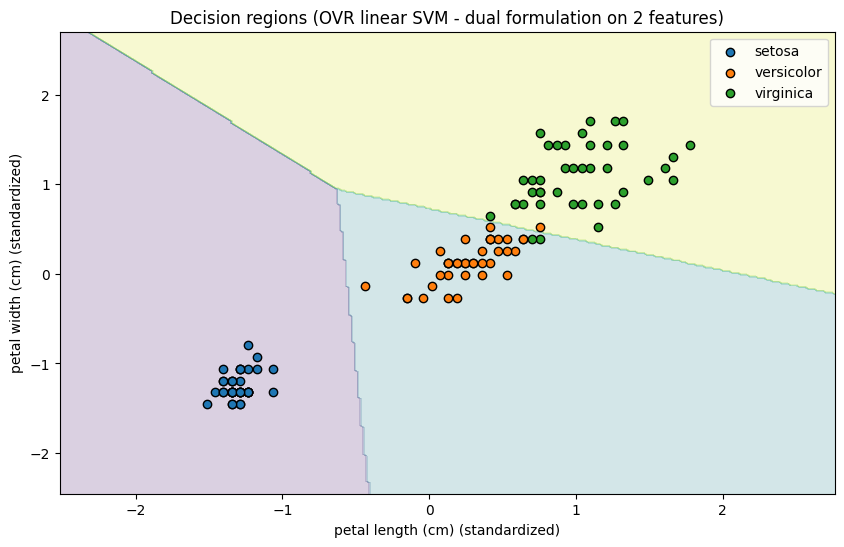


2D models (on petal features):
Class 0: w = [-1.4924 -1.2359], b = -1.8607, #SV = 4
Class 1: w = [ 1.2058 -1.0623], b = -0.3341, #SV = 119
Class 2: w = [2.4587 2.5724], b = -2.9973, #SV = 17


In [ ]:
# 2D Visualization (petal length vs petal width)

feature_indices = [2, 3]  # petal length, petal width
X2 = X[:, feature_indices]

X2_train_full, X2_test_full, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.2, random_state=42, stratify=y)
scaler2 = StandardScaler()
X2_train = scaler2.fit_transform(X2_train_full)
X2_test = scaler2.transform(X2_test_full)

models2 = train_ovr_svm_dual(X2_train, y2_train, C=C)

# Plot decision regions
h = 0.02
x_min, x_max = X2_train[:,0].min() - 1, X2_train[:,0].max() + 1
y_min, y_max = X2_train[:,1].min() - 1, X2_train[:,1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()]

Z = predict_ovr(models2, grid)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,6))
plt.contourf(xx, yy, Z, alpha=0.2)
for cls in np.unique(y2_train):
    pts = X2_train[y2_train == cls]
    plt.scatter(pts[:,0], pts[:,1], label=iris.target_names[cls], edgecolor='k')
plt.xlabel(iris.feature_names[feature_indices[0]] + " (standardized)")
plt.ylabel(iris.feature_names[feature_indices[1]] + " (standardized)")
plt.title("Decision regions (OVR linear SVM - dual formulation on 2 features)")
plt.legend()
plt.show()

print("\n2D models (on petal features):")
for cls, m in models2.items():
    w, b = m['w'], m['b']
    print(f"Class {cls}: w = {np.round(w,4)}, b = {np.round(b,4)}, #SV = {len(m['sv_idx'])}")